For this study, the Climate Change Twitter dataset was wrangled using Python and the Pandas library. The wrangling process involved data loading, removing duplicates, handling missing values, standardizing formats, extracting relevant features, and preparing the textual data for natural language processing.

### Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("The Climate Change Twitter Dataset.csv")

# Display first rows
df.head()

,created_at,id,lng,lat,topic,sentiment,stance,gender,temperature_avg,aggressiveness
0,2006-06-06 16:06:42+00:00,6132,NaN,NaN,Weather Extremes,-0.097180,neutral,female,NaN,aggressive
1,2006-07-23 21:52:30+00:00,13275,-73.949582,40.650104,Weather Extremes,0.575777,neutral,undefined,-1.114768,aggressive
2,2006-08-29 01:52:30+00:00,23160,NaN,NaN,Weather Extremes,0.500479,neutral,male,NaN,aggressive
3,2006-11-07 02:46:52+00:00,57868,NaN,NaN,Weather Extremes,0.032816,neutral,male,NaN,aggressive
4,2006-11-27 14:27:43+00:00,304553,NaN,NaN,Importance of Human Intervantion,-0.090428,neutral,male,NaN,aggressive


### Checking Dataset Structure

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15789411 entries, 0 to 15789410
Data columns (total 10 columns):
 #   Column           Dtype  
---  ------           -----  
 0   created_at       object 
 1   id               int64  
 2   lng              float64
 3   lat              float64
 4   topic            object 
 5   sentiment        float64
 6   stance           object 
 7   gender           object 
 8   temperature_avg  float64
 9   aggressiveness   object 
dtypes: float64(4), int64(1), object(5)
memory usage: 1.2+ GB


,id,lng,lat,sentiment,temperature_avg
count,1.578941e+07,5.307538e+06,5.307538e+06,1.578941e+07,5.307538e+06
mean,8.459853e+17,-4.639117e+01,3.408025e+01,2.536663e-03,1.245156e+00
std,3.113522e+17,7.523162e+01,2.229430e+01,4.379192e-01,3.799786e+00
min,6.132000e+03,-1.796670e+02,-9.000000e+01,-9.942049e-01,-2.328904e+01
25%,7.354169e+17,-9.536327e+01,3.315067e+01,-3.957429e-01,-1.140978e+00
50%,9.564851e+17,-7.703637e+01,3.995233e+01,-2.328273e-03,1.211522e+00
75%,1.049540e+18,-1.483154e-01,4.550884e+01,4.161248e-01,3.867153e+00
max,1.178912e+18,1.793830e+02,8.500000e+01,9.917458e-01,2.100350e+01


### Removing Duplicate Tweets

In [4]:
df = df.drop_duplicates(subset='id')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15789411 entries, 0 to 15789410
Data columns (total 10 columns):
 #   Column           Dtype  
---  ------           -----  
 0   created_at       object 
 1   id               int64  
 2   lng              float64
 3   lat              float64
 4   topic            object 
 5   sentiment        float64
 6   stance           object 
 7   gender           object 
 8   temperature_avg  float64
 9   aggressiveness   object 
dtypes: float64(4), int64(1), object(5)
memory usage: 1.2+ GB


### Handling Missing Values

In [5]:
# Check missing values
df.isnull().sum()


created_at                0
id                        0
lng                10481873
lat                10481873
topic                     0
sentiment                 0
stance                    0
gender                    0
temperature_avg    10481873
aggressiveness            0
dtype: int64

In [6]:

# remove rows with missing key variables
df = df.dropna(subset=['stance','sentiment'])

# fill missing temperature values
df['temperature_avg'] = df['temperature_avg'].fillna(df['temperature_avg'].mean())

### Converting Timestamp Format

In [7]:
df['created_at'] = pd.to_datetime(df['created_at'])

df['year'] = df['created_at'].dt.year
df['month'] = df['created_at'].dt.month

### Validating Geographic Data

In [8]:
df['gender'] = df['gender'].astype('category')
df['topic'] = df['topic'].astype('category')
df['stance'] = df['stance'].astype('category')
df['aggressiveness'] = df['aggressiveness'].astype('category')

In [37]:
df.head()

,created_at,year,month,lat,lng,topic,sentiment,stance,gender,temperature_avg,aggressiveness,stance_encoded,topic_enc,gender_enc,aggr_enc
0,2006-06-06 16:06:42+00:00,2006,6,NaN,NaN,Weather Extremes,-0.097180,neutral,female,1.245156,aggressive,2,9,0,0
1,2006-07-23 21:52:30+00:00,2006,7,40.650104,-73.949582,Weather Extremes,0.575777,neutral,undefined,-1.114768,aggressive,2,9,2,0
2,2006-08-29 01:52:30+00:00,2006,8,NaN,NaN,Weather Extremes,0.500479,neutral,male,1.245156,aggressive,2,9,1,0
3,2006-11-07 02:46:52+00:00,2006,11,NaN,NaN,Weather Extremes,0.032816,neutral,male,1.245156,aggressive,2,9,1,0
4,2006-11-27 14:27:43+00:00,2006,11,NaN,NaN,Importance of Human Intervantion,-0.090428,neutral,male,1.245156,aggressive,2,4,1,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15789411 entries, 0 to 15789410
Data columns (total 12 columns):
 #   Column           Dtype              
---  ------           -----              
 0   created_at       datetime64[ns, UTC]
 1   id               int64              
 2   lng              float64            
 3   lat              float64            
 4   topic            category           
 5   sentiment        float64            
 6   stance           category           
 7   gender           category           
 8   temperature_avg  float64            
 9   aggressiveness   category           
 10  year             int32              
 11  month            int32              
dtypes: category(4), datetime64[ns, UTC](1), float64(4), int32(2), int64(1)
memory usage: 903.5 MB


### Feature Selection

In [11]:
df = df[['created_at','year','month','lat','lng','topic','sentiment','stance','gender','temperature_avg','aggressiveness']]

### Saving the Clean Dataset

In [12]:
df.to_csv("clean_climate_data.csv", index=False)

## Descriptive Analytics

Descriptive analytics focuses on summarizing and visualizing data to understand its main characteristics and patterns. It provides insights into the distribution, central tendencies, and variability of variables within the dataset. In the context of the Climate Change Twitter dataset, descriptive analytics helps identify patterns in public sentiment, stance on climate change, geographical distribution of tweets, and relationships between environmental factors such as temperature and user sentiment.

### Summary Statistics

In [13]:
df.describe()

,year,month,lat,lng,sentiment,temperature_avg
count,1.578941e+07,1.578941e+07,5.307538e+06,5.307538e+06,1.578941e+07,1.578941e+07
mean,2.016639e+03,7.024364e+00,3.408025e+01,-4.639117e+01,2.536663e-03,1.245156e+00
std,2.514086e+00,3.647454e+00,2.229430e+01,7.523162e+01,4.379192e-01,2.203042e+00
min,2.006000e+03,1.000000e+00,-9.000000e+01,-1.796670e+02,-9.942049e-01,-2.328904e+01
25%,2.016000e+03,4.000000e+00,3.315067e+01,-9.536327e+01,-3.957429e-01,1.245156e+00
50%,2.018000e+03,7.000000e+00,3.995233e+01,-7.703637e+01,-2.328273e-03,1.245156e+00
75%,2.018000e+03,1.000000e+01,4.550884e+01,-1.483154e-01,4.161248e-01,1.245156e+00
max,2.019000e+03,1.200000e+01,8.500000e+01,1.793830e+02,9.917458e-01,2.100350e+01


### Distribution of Sentiment Scores

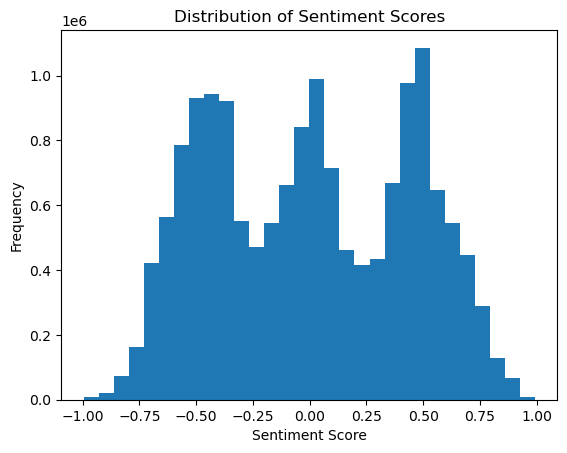

In [14]:

plt.hist(df['sentiment'], bins=30)
plt.title("Distribution of Sentiment Scores")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.show()

### Stance Distribution

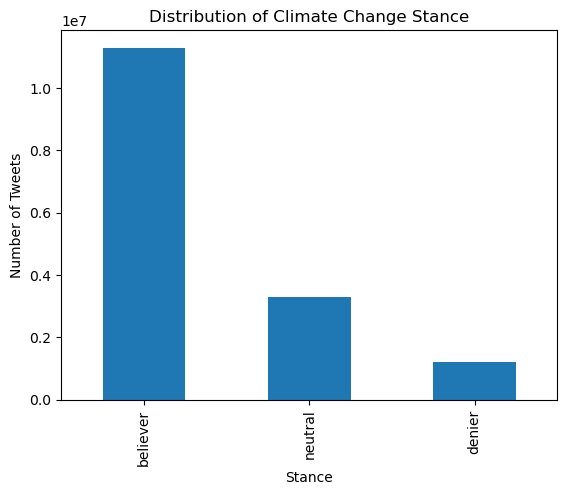

In [15]:
df['stance'].value_counts().plot(kind='bar')

plt.title("Distribution of Climate Change Stance")
plt.xlabel("Stance")
plt.ylabel("Number of Tweets")
plt.show()

### Gender Distribution

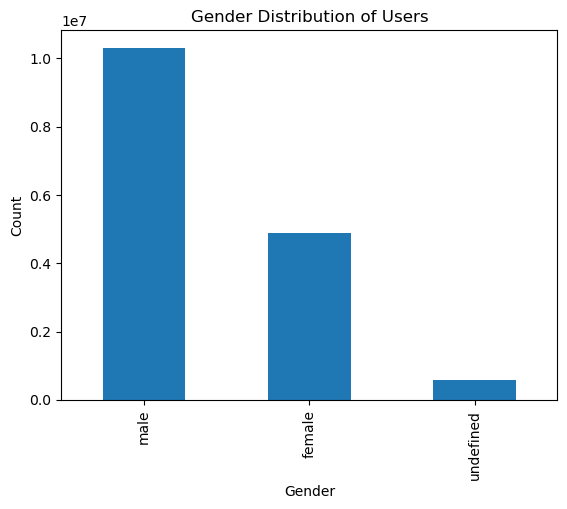

In [16]:
df['gender'].value_counts().plot(kind='bar')

plt.title("Gender Distribution of Users")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

### Sentiment vs Temperature

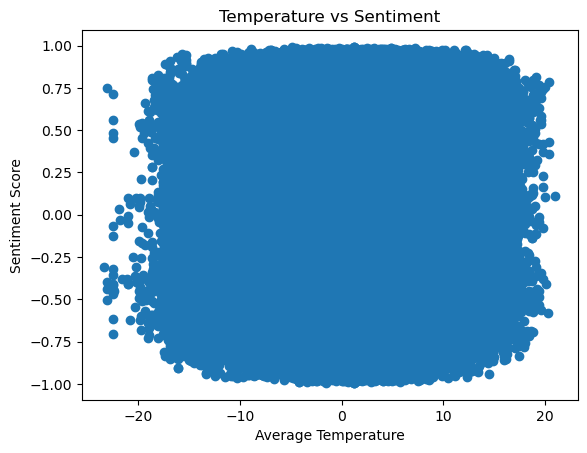

In [17]:
plt.scatter(df['temperature_avg'], df['sentiment'])

plt.title("Temperature vs Sentiment")
plt.xlabel("Average Temperature")
plt.ylabel("Sentiment Score")
plt.show()

### Climate Discussion Trends Over Time

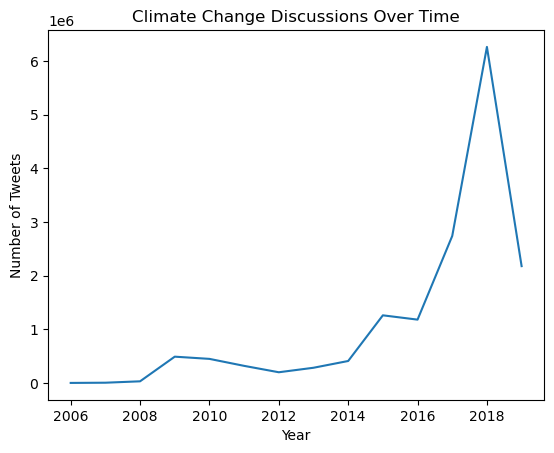

In [18]:
tweets_per_year = df['year'].value_counts().sort_index()

tweets_per_year.plot(kind='line')

plt.title("Climate Change Discussions Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Tweets")
plt.show()

### Topic Distribution

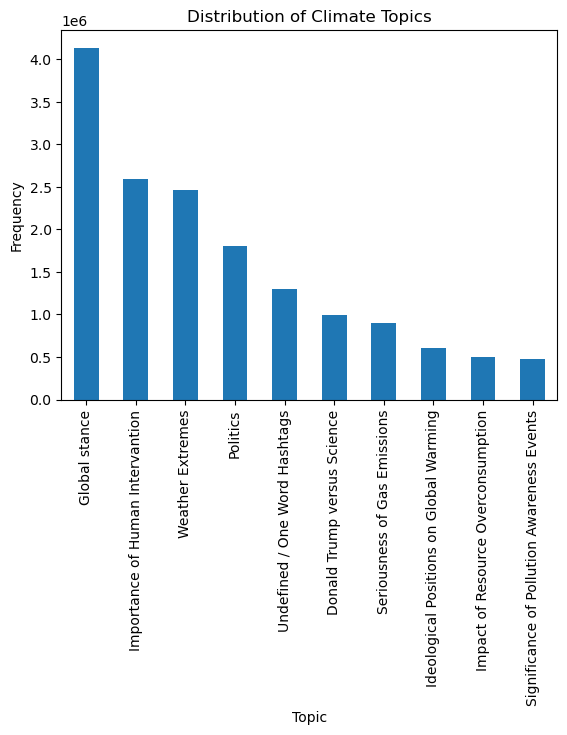

In [19]:
df['topic'].value_counts().plot(kind='bar')

plt.title("Distribution of Climate Topics")
plt.xlabel("Topic")
plt.ylabel("Frequency")
plt.show()

### Aggressiveness Distribution

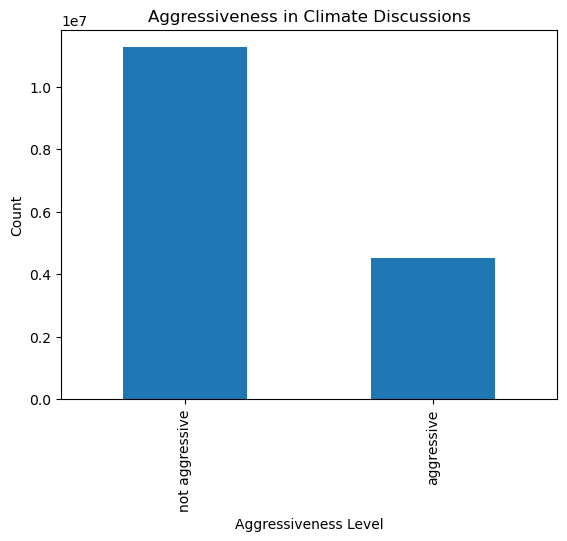

In [20]:
df['aggressiveness'].value_counts().plot(kind='bar')

plt.title("Aggressiveness in Climate Discussions")
plt.xlabel("Aggressiveness Level")
plt.ylabel("Count")
plt.show()

## Predictive Analytics

Predictive analytics involves using machine learning techniques to forecast outcomes based on historical data. In this study, multiple classification algorithms were implemented to predict the stance of Twitter users toward climate change. Using several models allows for comparison of performance and helps identify the most accurate algorithm for the dataset.

Three classification models were implemented: Logistic Regression, Random Forest, and Support Vector Machine (SVM). These models were evaluated using performance metrics including accuracy, precision, recall, F1-score, and ROC curve analysis.

### Feature Selection

In [26]:
features = df[['sentiment','temperature_avg','topic','gender','aggressiveness']]
target = df['stance_encoded']

### Encode Target Variable

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_topic = LabelEncoder()
le_gender = LabelEncoder()
le_aggr = LabelEncoder()
le_stance = LabelEncoder()

df['topic_enc'] = le_topic.fit_transform(df['topic'])
df['gender_enc'] = le_gender.fit_transform(df['gender'])
df['aggr_enc'] = le_aggr.fit_transform(df['aggressiveness'])

# Ensure the target variable is numeric encoded for modeling (creates it if it does not already exist)
df['stance_encoded'] = le_stance.fit_transform(df['stance'])

### Train-Test Split

In [38]:
from sklearn.model_selection import train_test_split

# Downsample for memory efficiency (avoids MemoryError during model training)
sample_size = min(200000, len(df))
df_sample = df.sample(sample_size, random_state=42)

features = df_sample[['sentiment','temperature_avg','topic_enc','gender_enc','aggr_enc']]
target = df_sample['stance_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.3, random_state=42
)

print('Sample size:', sample_size)
print('Train shape:', X_train.shape, y_train.shape)
print('Test shape:', X_test.shape, y_test.shape)

Sample size: 200000
Train shape: (140000, 5) (140000,)
Test shape: (60000, 5) (60000,)


### Model 1 - Logistic Regression

In [41]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

### Model 2 - Random Forest

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

### Model 3 - Support Vector Machine

In [46]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# Scale numeric features (SVM is sensitive to feature scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Use a linear SVM (much faster on larger datasets) with calibrated probabilities
base_svm = LinearSVC(max_iter=10000, random_state=42)
svm = CalibratedClassifierCV(estimator=base_svm, cv=3)

svm.fit(X_train_scaled, y_train)

svm_pred = svm.predict(X_test_scaled)